### **KODE UTAMA**

In [ ]:
# =============================================================================
# 1. INSTALASI LIBRARY
# =============================================================================
!pip install -q pandas openpyxl turftopic gensim scikit-learn sentence-transformers Sastrawi

# =============================================================================
# 2. IMPORT LIBRARY
# =============================================================================
import random
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from turftopic import SemanticSignalSeparation
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# =============================================================================
# 3. MEMBACA DATA DAN PEMBENTUKAN KORPUS
# =============================================================================
excel_file = "1DATA_FIX.xlsx"
csv_file = "1DATA_FIX.csv"

try:
    df_excel = pd.read_excel(excel_file)
    df_excel.to_csv(csv_file, index=False)
except Exception as e:
    print(f"[ERROR] {e} - Pastikan file '{excel_file}' sudah di-upload ke Colab.")

df = pd.read_csv(csv_file)
df['Judul'] = df['Judul'].fillna('')
df['Abstrak'] = df['Abstrak'].fillna('')
df['teks'] = df['Judul'] + ' ' + df['Abstrak']
corpus = df['teks'].tolist()

# =============================================================================
# 4. KONFIGURASI STOPWORDS & VECTORIZER
# =============================================================================
domain_stopwords = [
    "penelitian", "hasil", "metode", "data", "analisis",
    "menggunakan", "berdasarkan", "dilakukan", "dapat",
    "pengaruh", "signifikan", "positif", "negatif",
    "mahasiswa", "siswa", "peserta", "didik",
    "pembelajaran", "kelas", "universitas", "sebelas", "maret",
    "studi", "tujuan", "manfaat", "proses", "sistem",
    "aplikasi", "website", "media", "evaluasi", "efektivitas"
]
additional_stopwords = [
    "sangat", "terdapat", "memfasilitasi", "sebagai", "mempunyai",
    "berupa", "selain", "antar", "antara", "pihak", "para",
    "uns", "surakarta", "jawa", "tengah", "skripsi", "tugas", "akhir",
    "membangun", "merancang", "penerapan", "implementasi",
    "dikarenakan", "sehingga", "kemudian", "with", "untuk",
    "dari", "ini", "itu", "tersebut", "adalah", "yaitu", "eve", "ng", "er", "me", "strong"
]

factory = StopWordRemoverFactory()
sastrawi_stopwords = factory.get_stop_words()
all_stopwords = list(set(domain_stopwords + additional_stopwords + sastrawi_stopwords))

vectorizer = CountVectorizer(stop_words=all_stopwords, min_df=2)

# =============================================================================
# 5. OPTIMASI EMBEDDING (Hanya Dijalankan 1 Kali)
# =============================================================================
print("[INFO] Menghitung dokumen embedding menggunakan IndoBERT...")
model_name = "indobenchmark/indobert-base-p1"
encoder_model = SentenceTransformer(model_name)
precomputed_embeddings = encoder_model.encode(corpus, show_progress_bar=True)
print(f"[INFO] Embedding berhasil dibuat dengan bentuk matriks: {precomputed_embeddings.shape}")

# Wrapper Class untuk menjembatani embedding yang sudah ada ke dalam Turftopic
class PrecomputedEncoder:
    def __init__(self, embeddings):
        self.embeddings = embeddings
    def encode(self, sentences, **kwargs):
        return self.embeddings

[INFO] Menghitung dokumen embedding menggunakan IndoBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

[INFO] Embedding berhasil dibuat dengan bentuk matriks: (235, 768)


In [ ]:
import time

# =============================================================================
# 1. KONFIGURASI SEEDS & METRIC STORAGE
# =============================================================================
seeds = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
n_topics = 10
top_k = 10
raw_results = []

# Tokenisasi
analyzer = vectorizer.build_analyzer()
tokenized_texts = [analyzer(doc) for doc in corpus]
dictionary = Dictionary(tokenized_texts)

# =============================================================================
# 2. LOOPING EKSPERIMEN 10 RUN
# =============================================================================
print("\n=== MEMULAI EKSPERIMEN 10 RUNS ===")

for run_idx, seed in enumerate(seeds, 1):
    print(f"[RUN {run_idx}/10] Menggunakan Seed: {seed}...")

    # Catat waktu mulai
    run_start = time.time()

    # Mengontrol keacakan
    random.seed(seed)
    np.random.seed(seed)

    # Inisialisasi model S3
    model = SemanticSignalSeparation(
        n_components=n_topics,
        encoder=PrecomputedEncoder(precomputed_embeddings),
        vectorizer=vectorizer
    )

    # Fitting model
    model.fit_transform(corpus)

    topic_words = []
    if hasattr(model, 'components_') and hasattr(model.vectorizer, 'get_feature_names_out'):
        vocab = model.vectorizer.get_feature_names_out()
        for topic_weights in model.components_:
            top_indices = topic_weights.argsort()[:-top_k - 1:-1]
            topic_words.append([vocab[i] for i in top_indices])

    # Perhitungan 4 Metrik Evaluasi
    if len(topic_words) > 0:
        # a. Coherence Score (C_v)
        cm_v = CoherenceModel(topics=topic_words, texts=tokenized_texts, dictionary=dictionary, coherence='c_v')
        coherence_cv = cm_v.get_coherence()

        # b. NPMI Score (C_npmi)
        cm_npmi = CoherenceModel(topics=topic_words, texts=tokenized_texts, dictionary=dictionary, coherence='c_npmi', window_size=10)
        coherence_npmi = cm_npmi.get_coherence()

        # c. Topic Diversity
        all_top_words = []
        for words in topic_words:
            all_top_words.extend(words)
        topic_diversity = len(set(all_top_words)) / len(all_top_words)

        # d. Topic Quality (Diversity x NPMI)
        topic_quality = topic_diversity * coherence_npmi

        # e. Waktu Komputasi
        run_end = time.time()
        run_duration = run_end - run_start

        # Simpan hasil sementara
        raw_results.append({
            'Run': run_idx,
            'Seed': seed,
            'Coherence_Cv': coherence_cv,
            'Coherence_NPMI': coherence_npmi,
            'Topic_Diversity': topic_diversity,
            'Topic_Quality': topic_quality,
            'Computation_Time': run_duration
        })

# =============================================================================
# 3. PEMBUATAN DATAFRAME MENTAH & EKSPOR CSV
# =============================================================================
df_raw_results = pd.DataFrame(raw_results)
df_raw_results.to_csv("s3_raw_eval_results.csv", index=False)
print("\n[INFO] Eksperimen selesai! Tabel hasil mentah berhasil disimpan ke 's3_raw_eval_results.csv'")
display(df_raw_results)

[14:17:21] Documents encoded.                                                                         ]8;id=216109;file:///usr/local/lib/python3.12/dist-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=485050;file:///usr/local/lib/python3.12/dist-packages/turftopic/models/decomp.py#144\144]8;;\


=== MEMULAI EKSPERIMEN 10 RUNS ===
[RUN 1/10] Menggunakan Seed: 10...


Output()

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not 
converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(

[14:17:22] Decomposition done.                                                                        ]8;id=849995;file:///usr/local/lib/python3.12/dist-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=168012;file:///usr/local/lib/python3.12/dist-packages/turftopic/models/decomp.py#151\151]8;;\

...

           Term extraction done.                                                                      ]8;id=84047;file:///usr/local/lib/python3.12/dist-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=772497;file:///usr/local/lib/python3.12/dist-packages/turftopic/models/decomp.py#154\154]8;;\

           Vocabulary encoded.                                                                        ]8;id=978281;file:///usr/local/lib/python3.12/dist-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=678953;file:///usr/local/lib/python3.12/dist-packages/turftopic/models/decomp.py#164\164]8;;\

           Model fitting done.                                                                        ]8;id=324435;file:///usr/local/lib/python3.12/dist-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=879655;file:///usr/local/lib/python3.12/dist-packages/turftopic/models/decomp.py#184\184]8;;\


[INFO] Eksperimen selesai! Tabel hasil mentah berhasil disimpan ke 's3_raw_eval_results.csv'


,Run,Seed,Coherence_Cv,Coherence_NPMI,Topic_Diversity,Topic_Quality,Computation_Time
0,1,10,0.597256,-0.505196,0.88,-0.444573,1.759423
1,2,20,0.579433,-0.500171,0.88,-0.440150,0.898989
2,3,30,0.571234,-0.501112,0.89,-0.445990,1.754366
3,4,40,0.570884,-0.488539,0.90,-0.439685,1.976593
4,5,50,0.574760,-0.509266,0.91,-0.463432,1.696681
5,6,60,0.573369,-0.504932,0.92,-0.464538,2.100127
6,7,70,0.596292,-0.501971,0.91,-0.456794,1.934771
7,8,80,0.598633,-0.513818,0.89,-0.457298,3.087792
8,9,90,0.589052,-0.512724,0.93,-0.476834,2.173891
9,10,100,0.595512,-0.507222,0.79,-0.400706,1.457928


In [ ]:
# =============================================================================
# Perhitungan Ringkasan Statistik Deskriptif
# =============================================================================
print("\n=== MEMPROSES RINGKASAN STATISTIK ===")

metrics = ['Coherence_Cv', 'Coherence_NPMI', 'Topic_Diversity', 'Topic_Quality', "Computation_Time"]
summary_data = []

for metric in metrics:
    mean_val = df_raw_results[metric].mean()
    sd_val = df_raw_results[metric].std()
    min_val = df_raw_results[metric].min()
    max_val = df_raw_results[metric].max()

    summary_data.append({
        'Metrik': metric,
        'Mean (Titik Tengah)': mean_val,
        'Standard Deviation (SD)': sd_val,
        'Batas Bawah (Min)': min_val,
        'Batas Bawah (Mean - SD)': mean_val - sd_val,
        'Batas Atas (Max)': max_val,
        'Batas Atas (Mean + SD)': mean_val + sd_val
    })

# Ringkasan & Ekspor CSV
df_stat_summary = pd.DataFrame(summary_data)
df_stat_summary.to_csv("s3_stat_summary_results.csv", index=False)
print("[INFO] Ringkasan statistik berhasil disimpan ke 's3_stat_summary_results.csv'")
display(df_stat_summary)


=== MEMPROSES RINGKASAN STATISTIK ===
[INFO] Ringkasan statistik berhasil disimpan ke 's3_stat_summary_results.csv'


,Metrik,Mean (Titik Tengah),Standard Deviation (SD),Batas Bawah (Min),Batas Bawah (Mean - SD),Batas Atas (Max),Batas Atas (Mean + SD)
0,Coherence_Cv,0.584643,0.011781,0.570884,0.572862,0.598633,0.596423
1,Coherence_NPMI,-0.504495,0.007277,-0.513818,-0.511773,-0.488539,-0.497218
2,Topic_Diversity,0.890000,0.038873,0.790000,0.851127,0.930000,0.928873
3,Topic_Quality,-0.449000,0.020764,-0.476834,-0.469763,-0.400706,-0.428236
4,Computation_Time,1.884056,0.558789,0.898989,1.325267,3.087792,2.442845


### **VISUALISASI**

In [ ]:
# Setelah model.fit_transform
fig = model.concept_compass(topic_x=0, topic_y=1)
fig.show()

/usr/local/lib/python3.12/dist-packages/turftopic/models/decomp.py:703: UserWarning: concept_compass() is deprecated and will be removed in version 1.0.0. Use plot_concept_compass() instead.
  warnings.warn(



       TOP 10 KATA UNTUK TIAP TOPIK     


,Topic 0,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9
0,afektif,alessi,90,bagian,36,accuracy,application,backlog,83,banyaknya
1,alat,240,2021,banyak,adaptif,based,50,_x000d_,76,27
2,96,82,405,24,302,63,3d,angket,2022,20
3,22,2d,87,akurat,aspire,36,backlog,alpha,99,admin
4,apa,balik,27,62,baru,arah,65,2021,aspeknya,akurat
5,arah,66,58,arti,19,91,36,58,91,62
6,001,1993,09,40,80,baru,ajaran,405,bangun,44
7,arsitektur,bangun,augmented,22,482,administrasi,antarmuka,97,artikel,abad
8,antaranya,89,2018,25,09,39,1993,56,angket,2010
9,alpha,akademik,anak,482,analisa,adapun,akurat,aspire,155,23


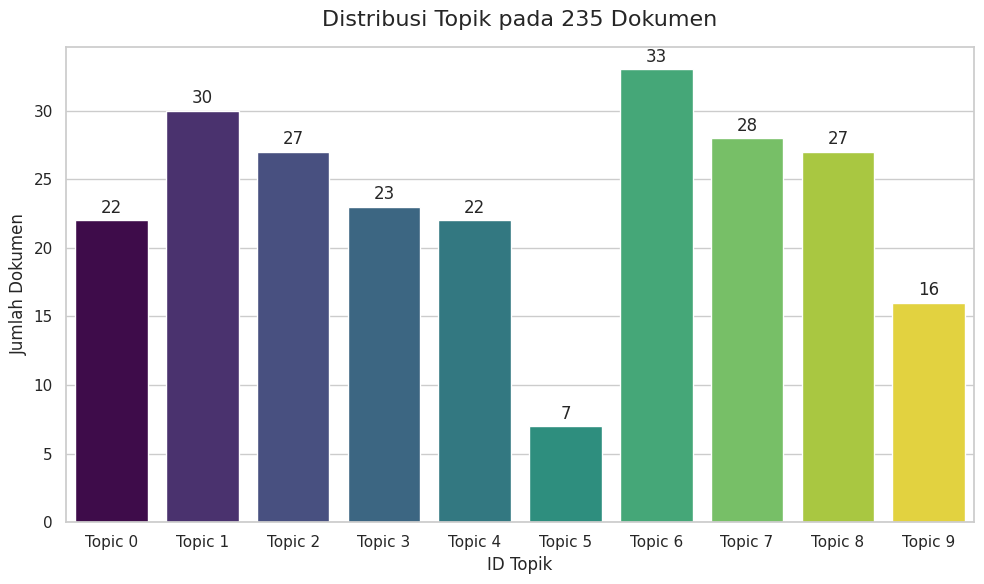

In [ ]:
# =============================================================================
# VISUALISASI HASIL S3 MENGGUNAKAN MATPLOTLIB & SEABORN
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. TAMPILKAN TOP KATA PER TOPIK DALAM BENTUK TABEL WARNA
top_k = 10
topic_words_dict = {}

# Ekstrak kata-kata dari model
vocab = model.vectorizer.get_feature_names_out()
for topic_idx, topic_weights in enumerate(model.components_):
    top_indices = topic_weights.argsort()[:-top_k - 1:-1]
    topic_words_dict[f"Topic {topic_idx}"] = [vocab[i] for i in top_indices]

# Buat DataFrame
df_topics = pd.DataFrame(topic_words_dict)

print("\n========================================")
print("       TOP 10 KATA UNTUK TIAP TOPIK     ")
print("========================================")
display(df_topics)

# 2. VISUALISASI DISTRIBUSI TOPIK DI SELURUH DOKUMEN
document_topic_matrix = model.transform(corpus)
dominant_topics = np.argmax(document_topic_matrix, axis=1)

# Hitung jumlah dokumen per topik
topic_counts = pd.Series(dominant_topics).value_counts().sort_index()

# Setup Plot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Buat Bar Chart
ax = sns.barplot(
    x=topic_counts.index,
    y=topic_counts.values,
    hue=topic_counts.index,
    palette="viridis",
    legend=False
)

plt.title('Distribusi Topik pada 235 Dokumen', fontsize=16, pad=15)
plt.xlabel('ID Topik', fontsize=12)
plt.ylabel('Jumlah Dokumen', fontsize=12)

# Tambahkan label angka di atas setiap bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.xticks(range(len(topic_counts)), [f"Topic {i}" for i in topic_counts.index])
plt.tight_layout()
plt.show()

Jumlah topik: 10
Jumlah dokumen: 235

=== Rata-rata skor per topik ===
Topik 1: 0.0000
Topik 2: -0.0000
Topik 3: 0.0000
Topik 4: 0.0000
Topik 5: 0.0000
Topik 6: -0.0000
Topik 7: 0.0000
Topik 8: 0.0000
Topik 9: -0.0000
Topik 10: -0.0000

=== Distribusi dokumen berdasarkan topik dominan ===
Topik 1: 22 dokumen (9.4%)
Topik 2: 30 dokumen (12.8%)
Topik 3: 27 dokumen (11.5%)
Topik 4: 23 dokumen (9.8%)
Topik 5: 22 dokumen (9.4%)
Topik 6: 7 dokumen (3.0%)
Topik 7: 33 dokumen (14.0%)
Topik 8: 28 dokumen (11.9%)
Topik 9: 27 dokumen (11.5%)
Topik 10: 16 dokumen (6.8%)

=== Kata-kata teratas setiap topik ===

Topik 1:
  afektif, alat, 96, 22, apa, arah, 001, arsitektur, antaranya, alpha

Topik 2:
  alessi, 240, 82, 2d, balik, 66, 1993, bangun, 89, akademik

Topik 3:
  90, 2021, 405, 87, 27, 58, 09, augmented, 2018, anak

Topik 4:
  bagian, banyak, 24, akurat, 62, arti, 40, 22, 25, 482

Topik 5:
  36, adaptif, 302, aspire, baru, 19, 80, 482, 09, analisa

Topik 6:
  accuracy, based, 63, 36, arah, 9

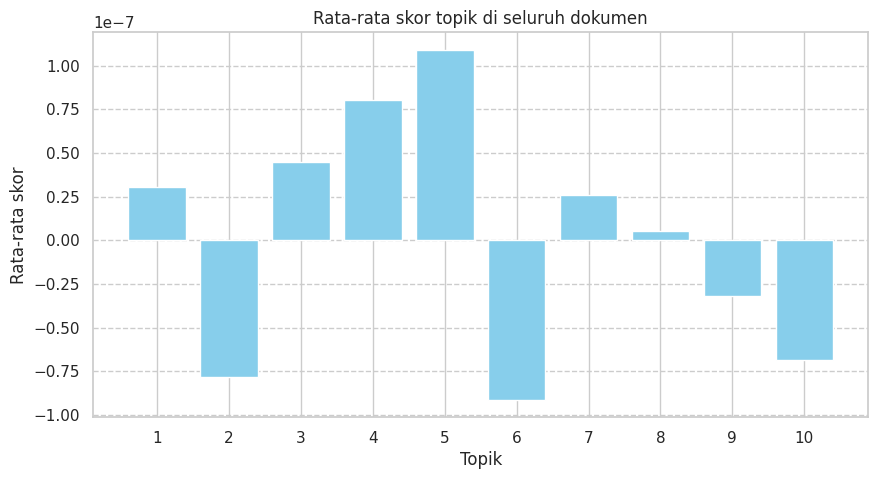

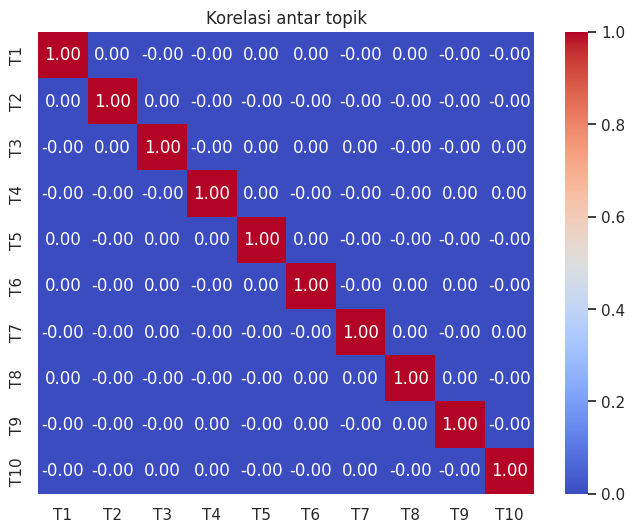

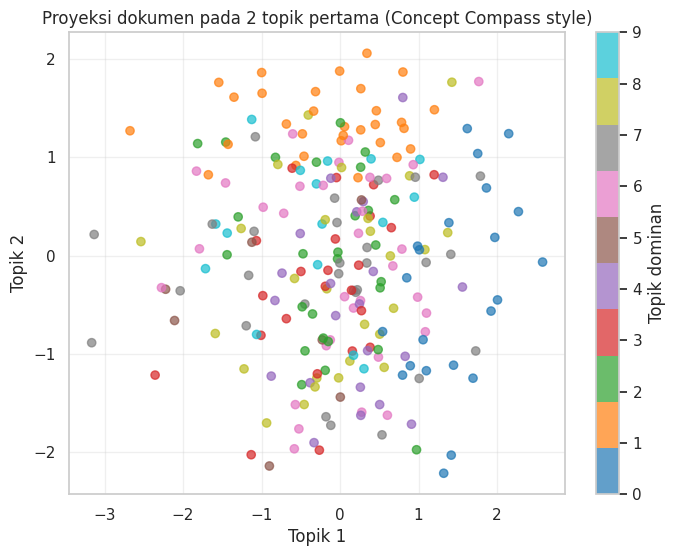

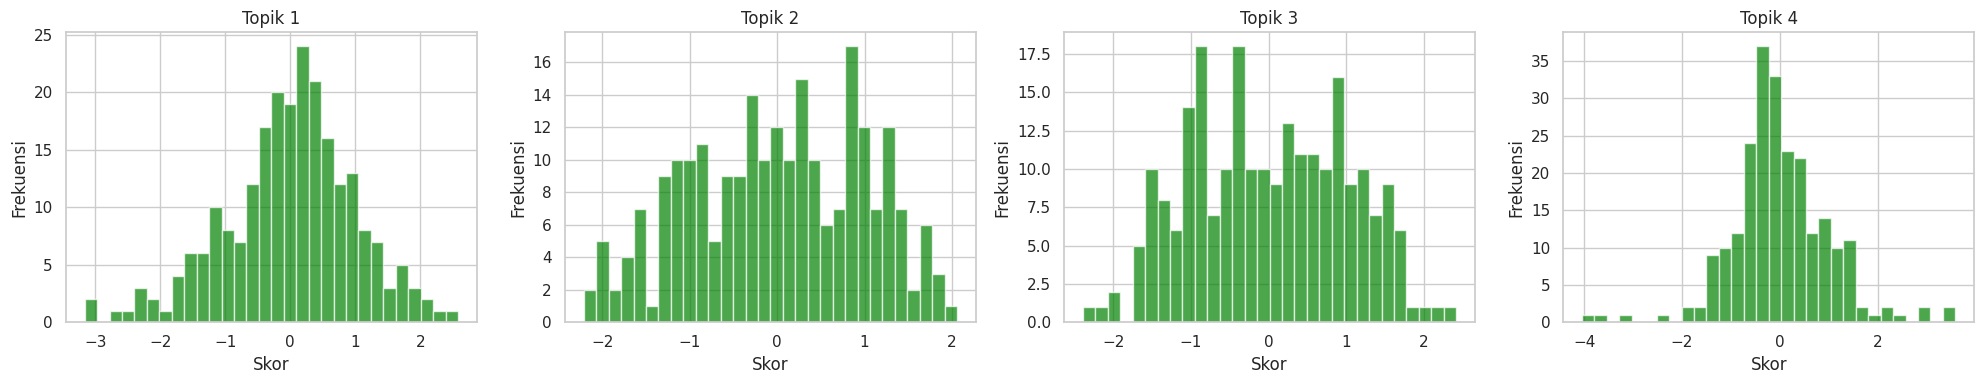


=== Ringkasan Topik ===
 Topik  Rata-rata skor  Jumlah dokumen dominan                                                     Kata teratas (10)
     1    3.069005e-08                      22   afektif, alat, 96, 22, apa, arah, 001, arsitektur, antaranya, alpha
     2   -7.812013e-08                      30            alessi, 240, 82, 2d, balik, 66, 1993, bangun, 89, akademik
     3    4.502053e-08                      27                  90, 2021, 405, 87, 27, 58, 09, augmented, 2018, anak
     4    8.021264e-08                      23                 bagian, banyak, 24, akurat, 62, arti, 40, 22, 25, 482
     5    1.090638e-07                      22              36, adaptif, 302, aspire, baru, 19, 80, 482, 09, analisa
     6   -9.130925e-08                       7     accuracy, based, 63, 36, arah, 91, baru, administrasi, 39, adapun
     7    2.601362e-08                      33 application, 50, 3d, backlog, 65, 36, ajaran, antarmuka, 1993, akurat
     8    5.516600e-09                 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# 1. Pastikan Anda memiliki variabel-variabel berikut:
#    - model : objek hasil fitting S³ (misal dari s3.fit_transform())
#    - corpus : list of string (teks asli) - diperlukan untuk transform jika doc_topic_matrix_ belum ada
#    Jika model sudah memiliki metode .transform(), kita bisa dapatkan skor dokumen.
# =====================================================

# Coba dapatkan skor dokumen per topik (doc_topic_scores)
# Jika model memiliki atribut .doc_topic_matrix_ (hasil fit_transform), gunakan itu.
# Jika tidak, gunakan model.transform(corpus).

if hasattr(model, 'doc_topic_matrix_'):
    doc_topic_matrix = model.doc_topic_matrix_          # bentuk (n_dokumen, n_topik)
elif hasattr(model, 'transform'):
    doc_topic_matrix = model.transform(corpus)         # hitung ulang
else:
    raise ValueError("Tidak ditemukan skor dokumen. Pastikan model memiliki .doc_topic_matrix_ atau berikan corpus untuk transform.")

n_topics = doc_topic_matrix.shape[1]
n_docs = doc_topic_matrix.shape[0]
print(f"Jumlah topik: {n_topics}")
print(f"Jumlah dokumen: {n_docs}")

# =====================================================
# 2. Dapatkan kata-kata per topik
# =====================================================
# Umumnya komponen topik ada di model.components_ (untuk SVD)
# Atau model.topic_matrix_ untuk S³
if hasattr(model, 'components_'):
    components = model.components_      # shape (n_topik, n_kata)
elif hasattr(model, 'topic_matrix_'):
    components = model.topic_matrix_
else:
    components = None
    print("Peringatan: Tidak ditemukan komponen topik. Kata per topik tidak bisa ditampilkan.")

# Nama fitur (kata) – Anda perlu menyediakan vectorizer atau daftar kata
# Jika Anda punya vectorizer (TF-IDF), gunakan get_feature_names_out()
# Jika tidak, masukkan secara manual.
if 'vectorizer' in locals():
    terms = vectorizer.get_feature_names_out()
elif hasattr(model, 'feature_names_'):
    terms = model.feature_names_
else:
    # Alternatif: jika components tidak None, buat dummy nama fitur
    if components is not None:
        terms = [f"kata_{i}" for i in range(components.shape[1])]
    else:
        terms = []

# =====================================================
# 3. Analisis distribusi topik
# =====================================================
# a. Rata-rata skor topik
mean_scores = doc_topic_matrix.mean(axis=0)
print("\n=== Rata-rata skor per topik ===")
for i, ms in enumerate(mean_scores):
    print(f"Topik {i+1}: {ms:.4f}")

# b. Topik dominan per dokumen (argmax)
dominant_topic = np.argmax(doc_topic_matrix, axis=1)
topic_counts = np.bincount(dominant_topic, minlength=n_topics)
print("\n=== Distribusi dokumen berdasarkan topik dominan ===")
for i in range(n_topics):
    print(f"Topik {i+1}: {topic_counts[i]} dokumen ({100*topic_counts[i]/n_docs:.1f}%)")

# =====================================================
# 4. Tampilkan kata teratas per topik (jika ada components)
# =====================================================
n_top_words = 10
if components is not None and len(terms) > 0:
    print("\n=== Kata-kata teratas setiap topik ===")
    for topic_idx in range(n_topics):
        topic_vector = components[topic_idx]
        top_indices = topic_vector.argsort()[-n_top_words:][::-1]
        top_words = [terms[i] for i in top_indices if i < len(terms)]
        print(f"\nTopik {topic_idx+1}:")
        print("  " + ", ".join(top_words))

# =====================================================
# 5. Visualisasi
# =====================================================
# 5.1 Bar chart rata-rata topik
plt.figure(figsize=(10,5))
plt.bar(range(1, n_topics+1), mean_scores, color='skyblue')
plt.xlabel("Topik")
plt.ylabel("Rata-rata skor")
plt.title("Rata-rata skor topik di seluruh dokumen")
plt.xticks(range(1, n_topics+1))
plt.grid(axis='y', linestyle='--')
plt.show()

# 5.2 Heatmap korelasi antar topik
corr = np.corrcoef(doc_topic_matrix.T)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=[f"T{i+1}" for i in range(n_topics)],
            yticklabels=[f"T{i+1}" for i in range(n_topics)])
plt.title("Korelasi antar topik")
plt.show()

# 5.3 Scatter plot 2D (konsep kompas) - jika n_topik >= 2
if n_topics >= 2:
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(doc_topic_matrix[:,0], doc_topic_matrix[:,1],
                          c=dominant_topic, cmap='tab10', alpha=0.7)
    plt.xlabel("Topik 1")
    plt.ylabel("Topik 2")
    plt.title("Proyeksi dokumen pada 2 topik pertama (Concept Compass style)")
    plt.colorbar(scatter, label="Topik dominan")
    plt.grid(True, alpha=0.3)
    plt.show()

# 5.4 Histogram skor untuk 4 topik pertama (atau kurang)
n_hist = min(4, n_topics)
fig, axes = plt.subplots(1, n_hist, figsize=(5*n_hist, 4))
if n_hist == 1:
    axes = [axes]
for i in range(n_hist):
    axes[i].hist(doc_topic_matrix[:,i], bins=30, color='green', alpha=0.7)
    axes[i].set_title(f"Topik {i+1}")
    axes[i].set_xlabel("Skor")
    axes[i].set_ylabel("Frekuensi")
plt.tight_layout()
plt.show()

# =====================================================
# 6. Tabel ringkasan (DataFrame)
# =====================================================
if components is not None and len(terms) > 0:
    top_words_list = []
    for i in range(n_topics):
        top_idx = components[i].argsort()[-n_top_words:][::-1]
        top_words_list.append(", ".join([terms[j] for j in top_idx if j < len(terms)]))
else:
    top_words_list = ["(tidak tersedia)"] * n_topics

summary_df = pd.DataFrame({
    "Topik": range(1, n_topics+1),
    "Rata-rata skor": mean_scores,
    "Jumlah dokumen dominan": topic_counts,
    "Kata teratas (10)": top_words_list
})
print("\n=== Ringkasan Topik ===")
print(summary_df.to_string(index=False))

# Jika ingin simpan ke CSV
# summary_df.to_csv("ringkasan_topik.csv", index=False)

In [ ]:
# =============================================================================
# BLOK KODE BARU: VISUALISASI INTERAKTIF (BERTOPIC STYLE) MENGGUNAKAN PLOTLY
# =============================================================================
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Ekstrak kosakata, kata teratas, dan skor bobotnya dari model S3
vocab = model.vectorizer.get_feature_names_out()
n_topics = model.n_components
top_k_words = 10

topics_data = {}
for topic_idx, topic_weights in enumerate(model.components_):
    # Urutkan bobot kata dari yang terbesar
    top_indices = topic_weights.argsort()[:-top_k_words - 1:-1]
    topics_data[topic_idx] = {
        "words": [vocab[i] for i in top_indices],
        "scores": [topic_weights[i] for i in top_indices]
    }

# 2. Hitung distribusi dokumen berdasarkan argmax document_topic_matrix
# (Menggunakan matriks dari hasil training terakhir)
dominant_topics = np.argmax(document_topic_matrix, axis=1)
topic_counts = pd.Series(dominant_topics).value_counts().sort_index()

# -----------------------------------------------------------------------------
# VISUALISASI 1: INTERACTIVE TOPIC BARCHART (Melihat Bobot Kata Per Topik)
# -----------------------------------------------------------------------------
# Membuat grid subplot: 5 baris, 2 kolom (Total 10 topik)
fig_words = make_subplots(
    rows=5, cols=2,
    subplot_titles=[f"<b>Topic {i}</b>: " + ", ".join(topics_data[i]["words"][:3]) + "..." for i in range(n_topics)],
    horizontal_spacing=0.15,
    vertical_spacing=0.06
)

for i in range(n_topics):
    row = (i // 2) + 1
    col = (i % 2) + 1

    # Balik urutan agar kata dengan skor tertinggi berada di paling atas chart
    words = topics_data[i]["words"][::-1]
    scores = topics_data[i]["scores"][::-1]

    fig_words.add_trace(
        go.Bar(
            x=scores,
            y=words,
            orientation='h',
            marker=dict(
                color=scores,
                colorscale='Viridis',
                showscale=False
            ),
            hovertemplate="<b>Kata:</b> %{y}<br><b>Bobot:</b> %{x:.4f}<extra></extra>",
            showlegend=False
        ),
        row=row, col=col
    )

fig_words.update_layout(
    title_text="<span style='font-size:20px;'><b>Top Word Scores per Topic</b></span>",
    height=1500,
    width=1000,
    template="plotly_white",
    margin=dict(t=100, b=50, l=100, r=50)
)
fig_words.show()

# -----------------------------------------------------------------------------
# VISUALISASI 2: INTERACTIVE TOPIC DISTRIBUTION (Hover untuk melihat Top 10 Words)
# -----------------------------------------------------------------------------
# Membuat teks hover kustom berisi daftar 10 kata teratas untuk tiap bar topik
hover_texts = []
for i in range(n_topics):
    top_words_list = topics_data[i]["words"]
    words_formatted = "<br>".join([f"   {idx+1}. {word}" for idx, word in enumerate(top_words_list)])

    hover_text = (
        f"<b>Topic {i}</b><br>"
        f"Jumlah Dokumen Skripsi: {topic_counts.get(i, 0)}<br>"
        f"----------------------------<br>"
        f"<b>Top 10 Kata Dominan:</b><br>{words_formatted}"
    )
    hover_texts.append(hover_text)

# Membuat bar chart distribusi dokumen
fig_dist = go.Figure(data=[
    go.Bar(
        x=[f"Topic {i}" for i in range(n_topics)],
        y=[topic_counts.get(i, 0) for i in range(n_topics)],
        text=[topic_counts.get(i, 0) for i in range(n_topics)],
        textposition='auto',
        hoverinfo='text',
        hovertext=hover_texts,
        marker=dict(
            color=[topic_counts.get(i, 0) for i in range(n_topics)],
            colorscale='Cividis',
            line=dict(color='black', width=1)
        )
    )
])

fig_dist.update_layout(
    title_text="<span style='font-size:20px;'><b>Interactive Topic Distribution (Hover to Explore Words)</b></span>",
    xaxis_title="ID Topik",
    yaxis_title="Jumlah Dokumen Skripsi",
    template="plotly_white",
    height=550,
    width=950,
    margin=dict(t=100, b=50, l=50, r=50)
)
fig_dist.show()